In [1]:
#Librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap



from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Cargamos el dataset
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML/churn_data.csv")  # Modificar según ruta donde se almacene

print(df.head()) # Los datos cargaron correctamente


Mounted at /content/drive
   customerID  tenure PhoneService        Contract PaperlessBilling  \
0  7590-VHVEG       1           No  Month-to-month              Yes   
1  5575-GNVDE      34          Yes        One year               No   
2  3668-QPYBK       2          Yes  Month-to-month              Yes   
3  7795-CFOCW      45           No        One year               No   
4  9237-HQITU       2          Yes  Month-to-month              Yes   

               PaymentMethod  MonthlyCharges TotalCharges Churn  
0           Electronic check           29.85        29.85    No  
1               Mailed check           56.95       1889.5    No  
2               Mailed check           53.85       108.15   Yes  
3  Bank transfer (automatic)           42.30      1840.75    No  
4           Electronic check           70.70       151.65   Yes  


In [3]:
# Realizamos un breve ánalisis exploratorio
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 495.3+ KB


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']) # Elimnamos los nulos
df = df.drop(columns=['customerID']) # Eliminamos el ID

In [5]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


No hay valores nulos en el dataset. Observamos que algunas columnas tienen un tipo de dato incorrecto, como TotalCharges, que aparece como object pero debería ser numérica. Varias variables son categóricas binarias y se convertirán a 0/1 para facilitar el análisis y el modelado.

Finalmente, las variables MonthlyCharges y TotalCharges presentan una desviación significativa respecto a su media, lo que indica una amplia dispersión en sus valores

In [6]:
# Convertimos las variables categóricas binarias a 0 y 1,y aplicamos one-hot encoding a las variables categóricas nominales
df["Churn"] = df["Churn"].map({'Yes': 1, 'No': 0})
df["PhoneService"] = df["PhoneService"].map({'Yes': 1, 'No': 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod'], drop_first=True)

<Axes: >

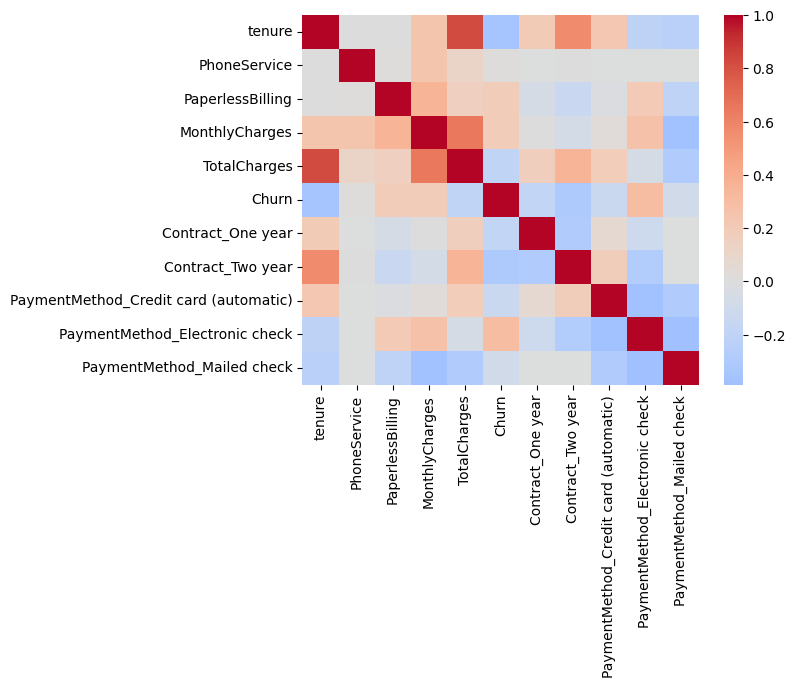

In [7]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)

In [8]:
df["Churn"].value_counts() # El dataset esta desbalanceado

,count
Churn,
0,5163
1,1869


Se muestran diversas correlaciones de intensidad moderada o fuerte. Como más hay menos abandono.


In [9]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Dividimos el data set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33, stratify=y)

In [10]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 50],
    'min_samples_split': [2, 5, 7],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'class_weight': ['balanced']}
rf = RandomForestClassifier()
grid_rf = GridSearchCV(rf, param_grid, cv=5)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [None, 20, 50], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5, 7],
                         'n_estimators': [100, 200]})

In [11]:
print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor precisión (CV):", grid_rf.best_score_)

Mejores parámetros: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor precisión (CV): 0.7809777777777778


In [12]:
# Evaluamos en el test
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)


print("Accuracy test:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy test: 0.7867803837953091
[[907 126]
 [174 200]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.71      1407
weighted avg       0.78      0.79      0.78      1407



El modelo solo es capaz de detectar el 58% de los clientes que se van. Pero acierta con el 84% de los que se quedan.

In [13]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

In [14]:
shap_values_class0 = shap_values[0]
shap_values_class1 = shap_values[1]

Nos enfocaremos en la clase 1, ya que nos interesa entender por qué los clientes se van.

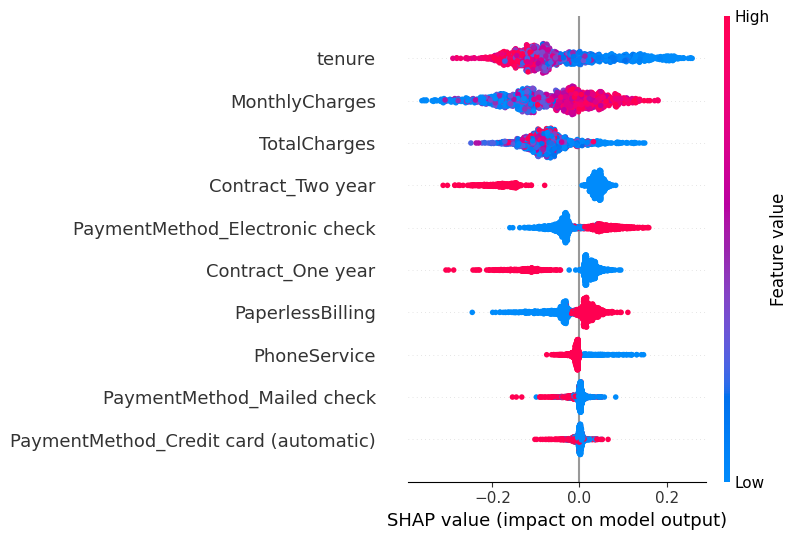

In [15]:
shap_values_class1 = shap_values[:, :, 1]  # toma solo la clase 1

shap.summary_plot(shap_values_class1, X_test)

Los factores que empujan al churn son llevar poco tiempo con la compañía y facturas altas.

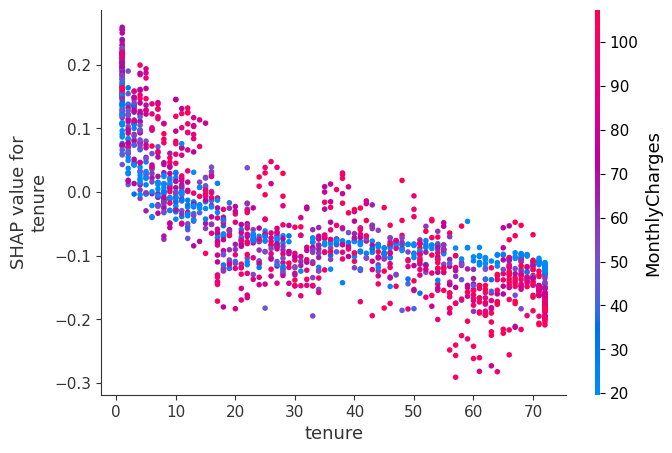

In [16]:
shap.dependence_plot("tenure", shap_values_class1, X_test)

Como era de esperar, llevar poco tiempo y tener cargos elevados causa abandono, aunque también con cargos más pequeños se puede observar cierta linealidad.

In [17]:
shap.initjs()
cliente = X_test.iloc[22]
shap.force_plot(
    explainer.expected_value[1],
    shap_values_class1[22],
    cliente)

En este ejemplo, el modelo predice que el cliente se va.
Los factores que aumentan la probabilidad de churn son: no tener contrato anual (Contract_One year = 0, Contract_Two year = 0) y el precio mensual elevado.
Por otro lado, los factores que disminuyen la probabilidad de churn son el tiempo que lleva como cliente y el total de pagos realizados


En conclusión, vemos que las facturas bajas y llevar cierto tiempo con la compañía ayudan a que la gente se quede, y al contrario, si son altas o llevas poco tiempo, hay más riesgo de abandono.

Con SHAP puedes ver cómo influye cada variable; por ejemplo, si la variable sexo estuviera muy desbalanceada, podrías pensar que el modelo está sesgado.

Una de las grandes ventajas de SHAP es que sirve para cualquier modelo y además es muy completo, puedes mirar la influencia de las variables en todo el conjunto de datos o en casos individuales, comparar variables y queda todo muy claro y fácil de entender.